# 1. Preprocessing

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


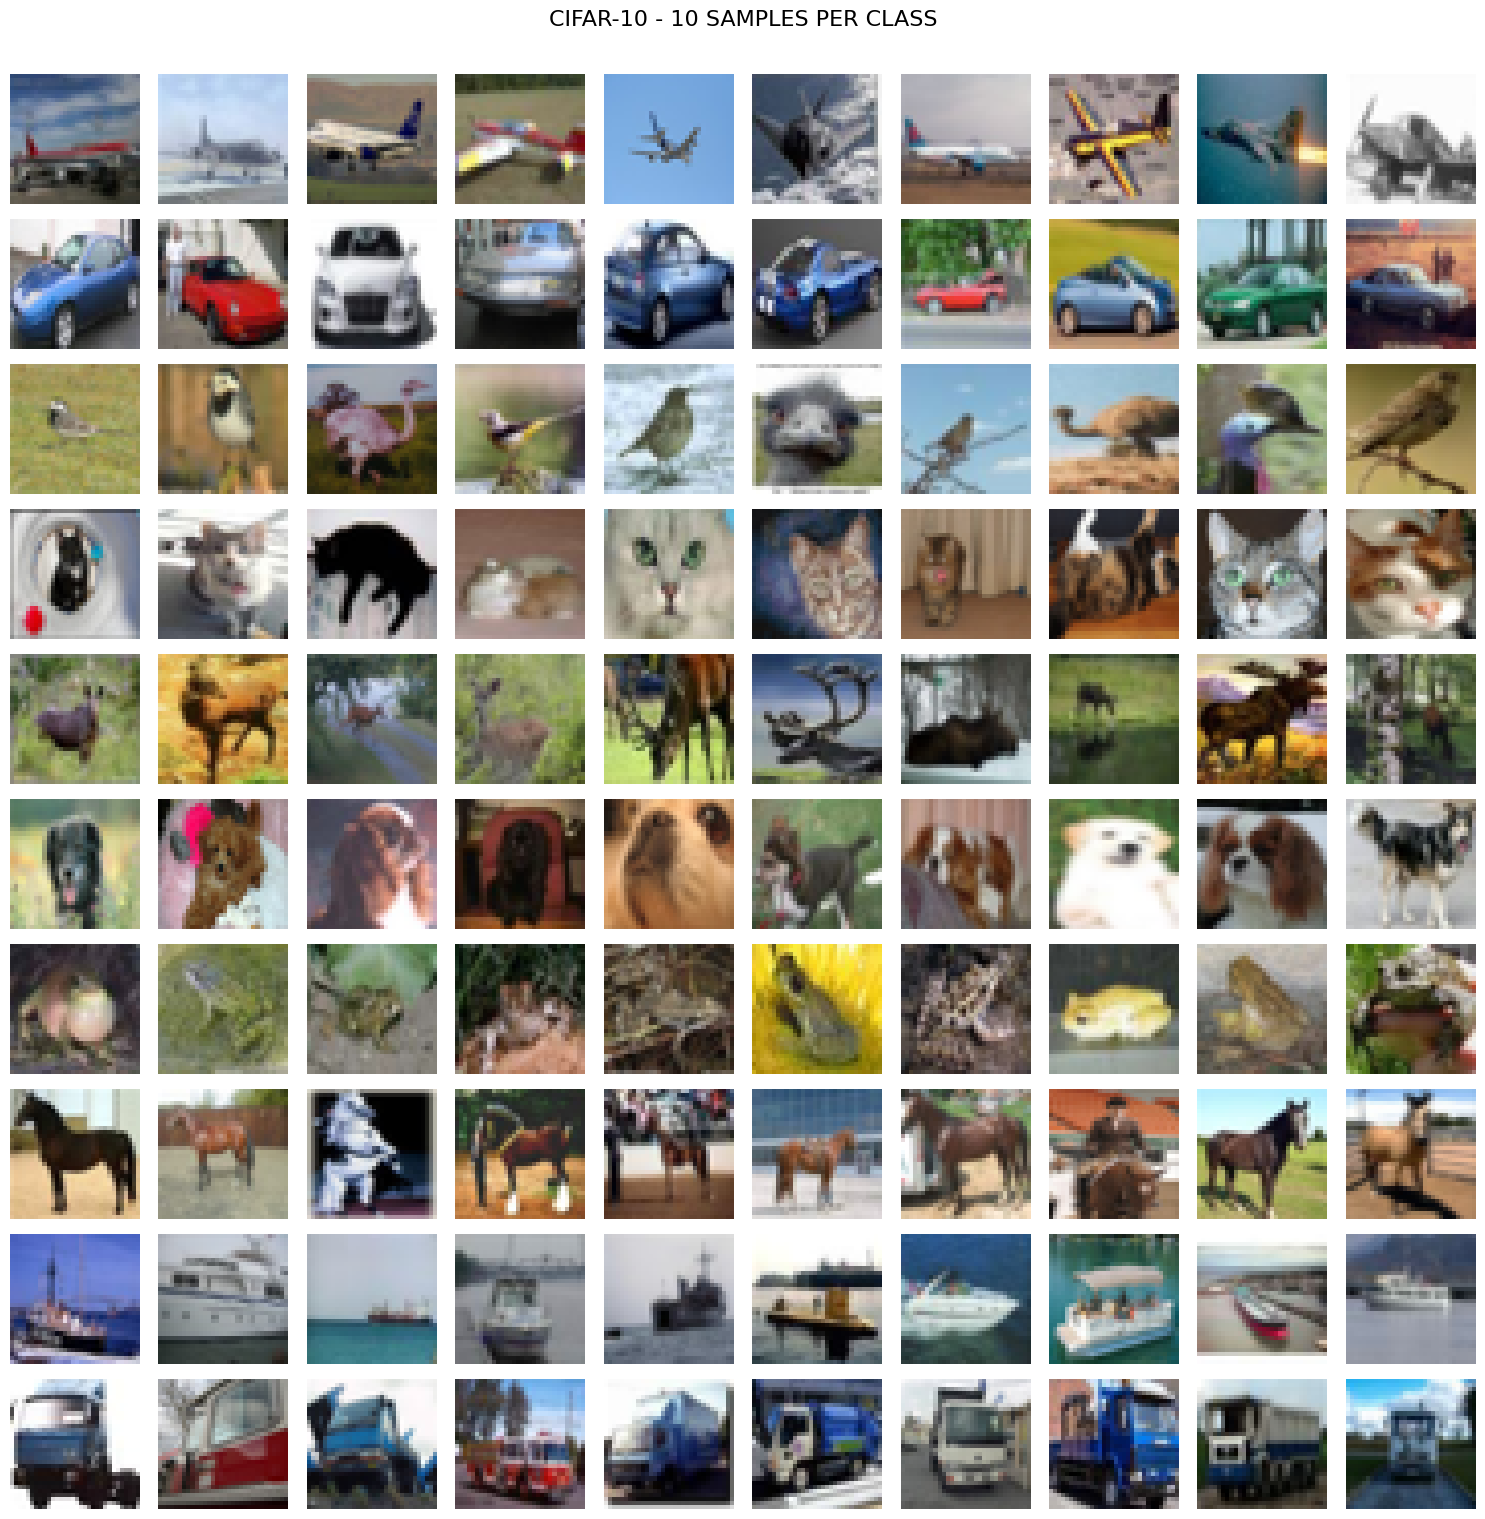

pixel min= 0.0 pixel max= 1.0
Training samples:   45000
Validation samples: 5000


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from keras.backend import clear_session
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ── Load Data ─────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape)
print(x_test.shape)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# ── Visualize 10x10 ───────────────────────────────────
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
fig.suptitle('CIFAR-10 - 10 SAMPLES PER CLASS', fontsize=16, y=1.01)

for class_idx in range(10):
    indices = np.where(y_train.flatten() == class_idx)[0]
    samples = np.random.choice(indices, 10, replace=False)
    for col, sample_idx in enumerate(samples):
        ax = axes[class_idx, col]
        ax.imshow(x_train[sample_idx])
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(class_names[class_idx], fontsize=9,
                          rotation=0, labelpad=50, va='center')

plt.tight_layout()
plt.show()

# ── Normalize ─────────────────────────────────────────
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0
print('pixel min=', x_train_norm.min(), 'pixel max=', x_train_norm.max())

# ── Train/Validation Split ────────────────────────────
x_train_split, x_val, y_train_split, y_val = train_test_split(
    x_train_norm, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print(f"Training samples:   {x_train_split.shape[0]}")
print(f"Validation samples: {x_val.shape[0]}")



# 2. Model Architecture (Data Augmentation)


In [2]:
# ── Build Model 7 ─────────────────────────────────────
clear_session()

model7 = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(100, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model7.summary()

# ── Data Augmentation ─────────────────────────────────
train_datagen = ImageDataGenerator(
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    rotation_range=10,
    zoom_range=0.1,
    shear_range=0.05,
    fill_mode='nearest'
)
train_datagen.fit(x_train_split)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       204,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 299,158 (1.14 MB)

 Trainable params: 299,158 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

# 3. Training

In [3]:
# ── Callbacks ─────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# ── Compile ───────────────────────────────────────────
model7.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ── Train with Augmentation ───────────────────────────
history = model7.fit(
    train_datagen.flow(x_train_split, y_train_split, batch_size=64),
    epochs=50,
    validation_data=(x_val, y_val),
    callbacks=[early_stop, lr_scheduler],   # ← added
    verbose=1
)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.2990 - loss: 1.8856 - val_accuracy: 0.4626 - val_loss: 1.4969 - learning_rate: 0.0010
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.4126 - loss: 1.6065 - val_accuracy: 0.5332 - val_loss: 1.3173 - learning_rate: 0.0010
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.4645 - loss: 1.4763 - val_accuracy: 0.5698 - val_loss: 1.1777 - learning_rate: 0.0010
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.4948 - loss: 1.4066 - val_accuracy: 0.5822 - val_loss: 1.1557 - learning_rate: 0.0010
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.5214 - loss: 1.3457 - val_accuracy: 0.6358 - val_loss: 1.0354 - learning_rate: 0.0010
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.5367 - loss: 1.2981 - val_accuracy: 0.6318 - val_loss: 1.0367 - learning_rate: 0.0010
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.5571 - l

# 4. Performance

Final Training Loss:     0.8273
Final Training Accuracy: 71.58%
Validation Loss:         0.6187
Validation Accuracy:     78.60%
Test Loss:               0.6458
Test Accuracy:           77.51%


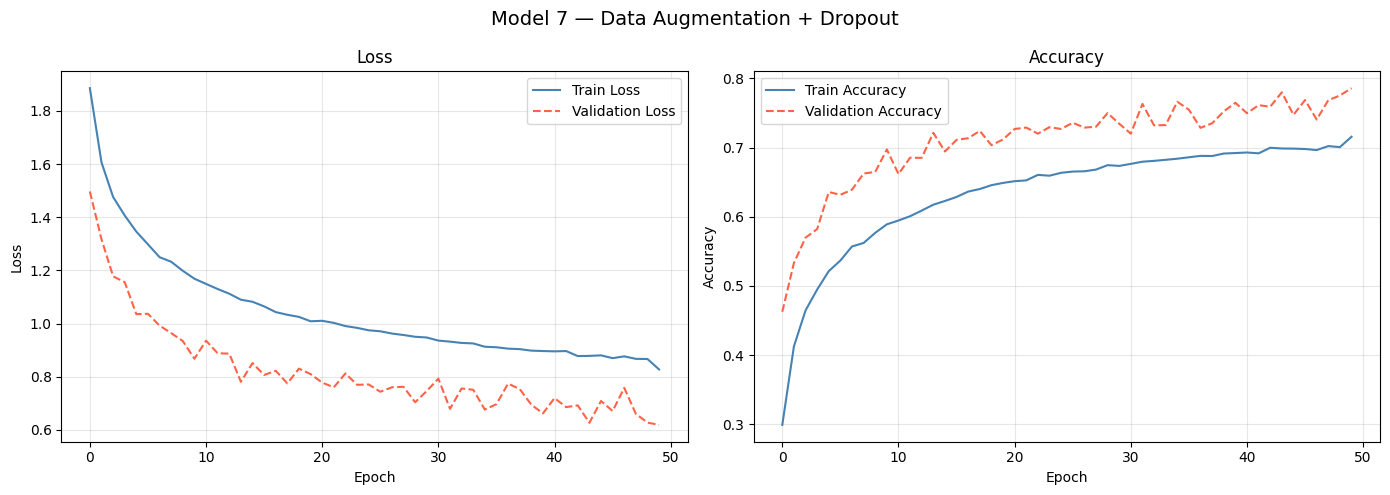

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

    airplane       0.84      0.80      0.82       500
  automobile       0.92      0.90      0.91       500
        bird       0.84      0.56      0.67       500
         cat       0.63      0.58      0.60       500
        deer       0.73      0.81      0.77       500
         dog       0.77      0.62      0.69       500
        frog       0.66      0.91      0.77       500
       horse       0.80      0.83      0.82       500
        ship       0.90      0.92      0.91       500
       truck       0.82      0.92      0.87       500

    accuracy                           0.79      5000
   macro avg       0.79      0.79      0.78      5000
weighted avg       0.79      0.79      0.78      5000



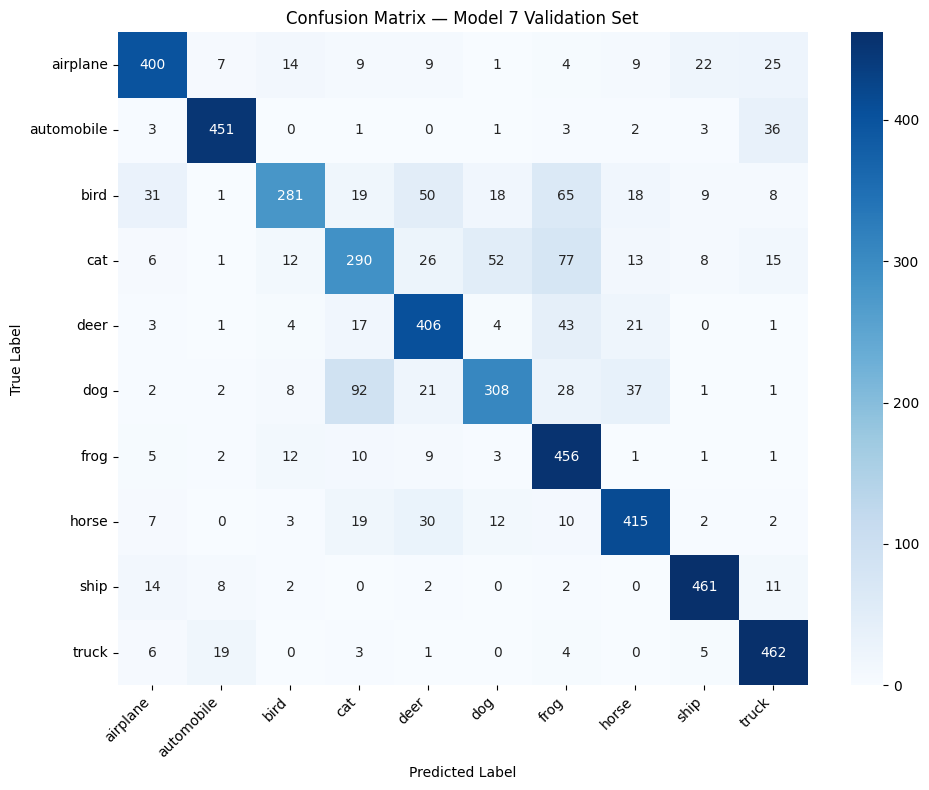

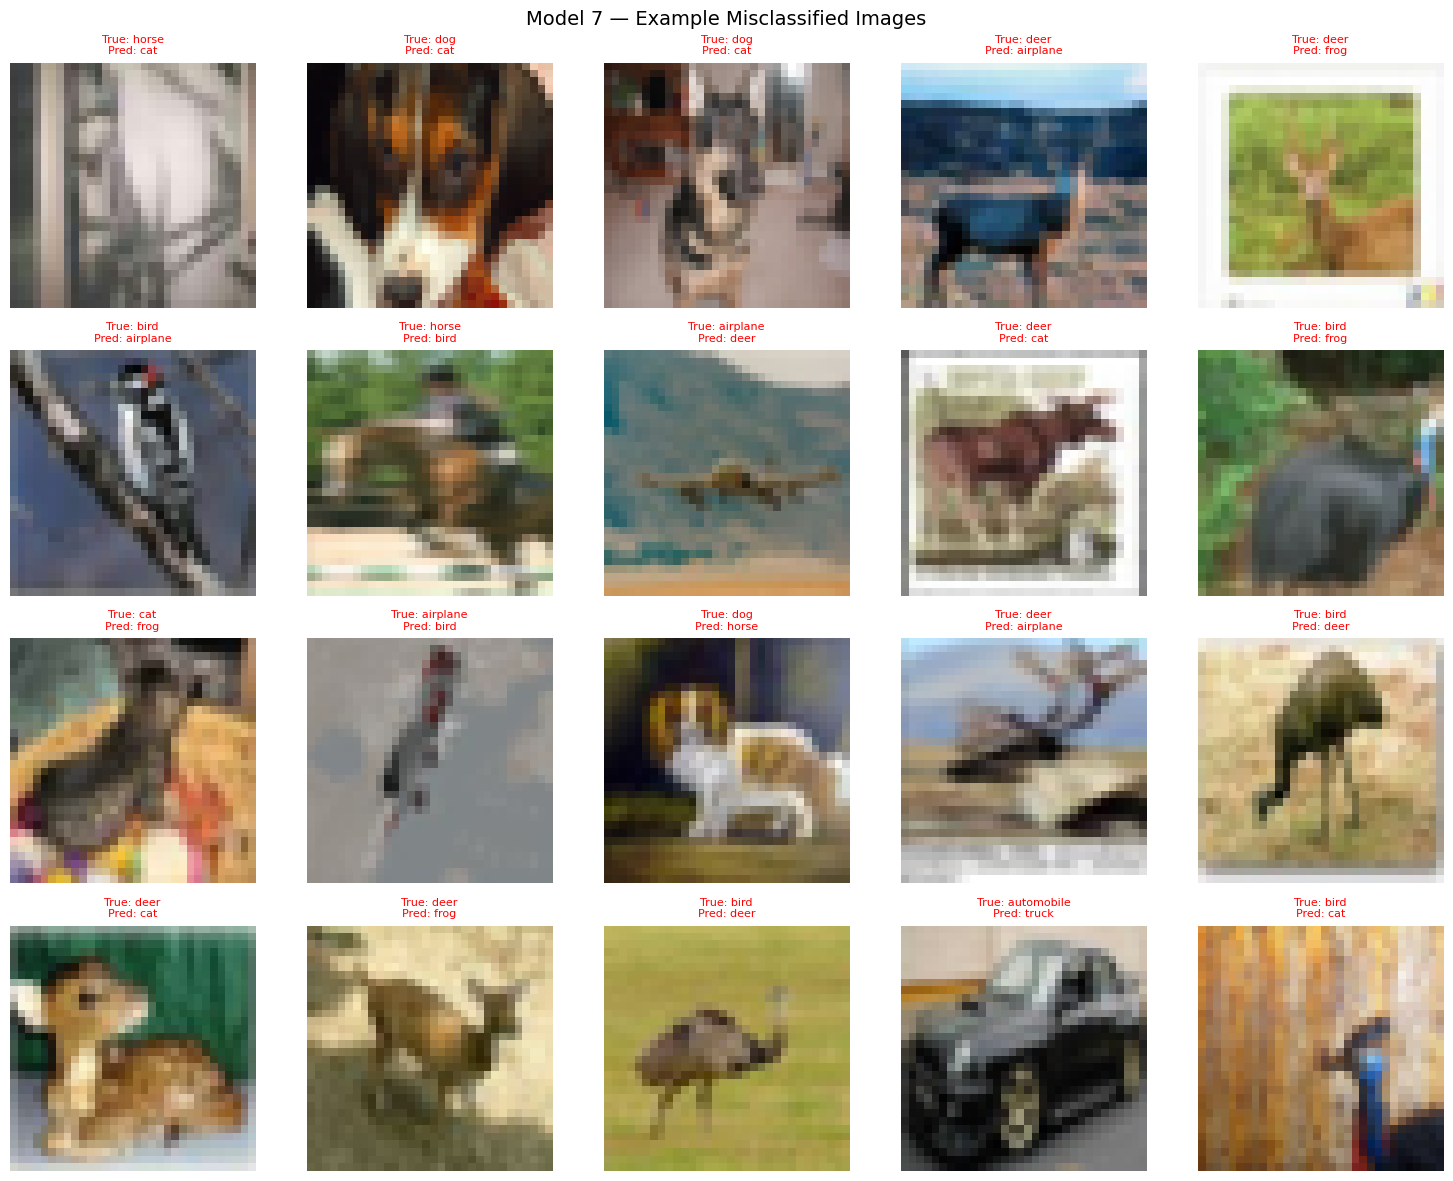

Total misclassified: 1070 / 5000


In [4]:
# ── Evaluate ──────────────────────────────────────────
val_loss7,  val_acc7  = model7.evaluate(x_val,       y_val,  verbose=0)
test_loss7, test_acc7 = model7.evaluate(x_test_norm, y_test, verbose=0)

print(f"Final Training Loss:     {history.history['loss'][-1]:.4f}")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"Validation Loss:         {val_loss7:.4f}")
print(f"Validation Accuracy:     {val_acc7*100:.2f}%")
print(f"Test Loss:               {test_loss7:.4f}")
print(f"Test Accuracy:           {test_acc7*100:.2f}%")

# ── Training Curves ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model 7 — Data Augmentation + Dropout', fontsize=14)

axes[0].plot(history.history['loss'],     label='Train Loss',      color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='tomato', linestyle='--')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato', linestyle='--')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Classification Report & Confusion Matrix ──────────
y_val_pred7 = np.argmax(model7.predict(x_val), axis=1)
y_val_true  = y_val.flatten()

print(classification_report(y_val_true, y_val_pred7, target_names=class_names))

cm7 = confusion_matrix(y_val_true, y_val_pred7)
plt.figure(figsize=(10, 8))
sns.heatmap(cm7, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Model 7 Validation Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ── Misclassified Images ──────────────────────────────
errors = np.where(y_val_pred7 != y_val_true)[0]

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('Model 7 — Example Misclassified Images', fontsize=14)

for i, idx in enumerate(errors[:20]):
    ax = axes[i//5, i%5]
    ax.imshow(x_val[idx])
    ax.axis('off')
    ax.set_title(f'True: {class_names[y_val_true[idx]]}\nPred: {class_names[y_val_pred7[idx]]}',
                 fontsize=8, color='red')

plt.tight_layout()
plt.show()
print(f"Total misclassified: {len(errors)} / {len(y_val_true)}")